In [1]:
import time
import functools
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, optimize

 - https://stackoverflow.com/questions/68266571/how-to-speed-up-the-ipopt-solver

In [2]:
n = 121
t = np.linspace(0, 12, n)
dt = t[1] - t[0]

In [3]:
x0 = np.array([
    0.5 * np.ones(shape=(n,)),
    0.7 * np.ones(shape=(n,)),
    np.zeros(shape=(n,)),
])

In [4]:
bounds = np.array([
    [(0.5, 0.5)] + [(-np.inf, +np.inf)] * (n - 1),
    [(0.7, 0.7)] + [(-np.inf, +np.inf)] * (n - 1),
    [(0., 1.)] * n,
])

In [5]:
def integrand(x):
    x1, x2, v = x.reshape(3, -1)
    return (x1 - 1.) ** 2 + (x2 - 1.) ** 2

In [6]:
def integral(x, dt):
    return integrate.trapezoid(y=integrand(x), dx=dt)

In [7]:
def constraint1(x, dt):
    x1, x2, v = x.reshape(3, -1)
    return + x1 - x1 * x2 - 0.4 * x1 * v - np.gradient(x1, dt)

In [8]:
def constraint2(x, dt):
    x1, x2, v = x.reshape(3, -1)
    return - x2 + x1 * x2 - 0.2 * x2 * v - np.gradient(x2, dt)

In [9]:
def system(t, x):
    return np.array([
        + x[0] - x[0] * x[1] - 0.4 * x[0] * x[2],
        - x[1] + x[0] * x[1] - 0.2 * x[1] * x[2],
        0.0,
    ])

In [10]:
sol1 = integrate.solve_ivp(system, [t.min(), t.max()], y0=[0.5, 0.7, 0.0], t_eval=t)
sol2 = integrate.solve_ivp(system, [t.min(), t.max()], y0=[0.5, 0.7, 1.0], t_eval=t)

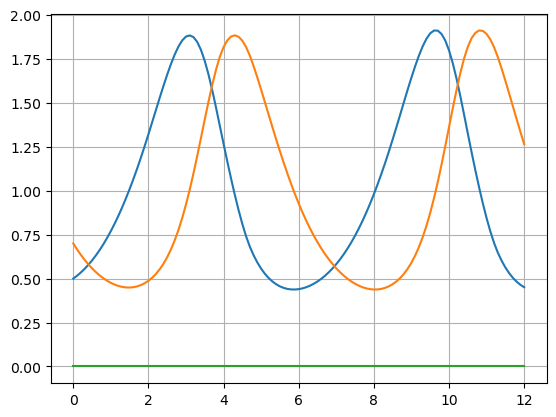

In [11]:
fig, axe = plt.subplots()
axe.plot(sol1.t, sol1.y.T)
axe.grid()

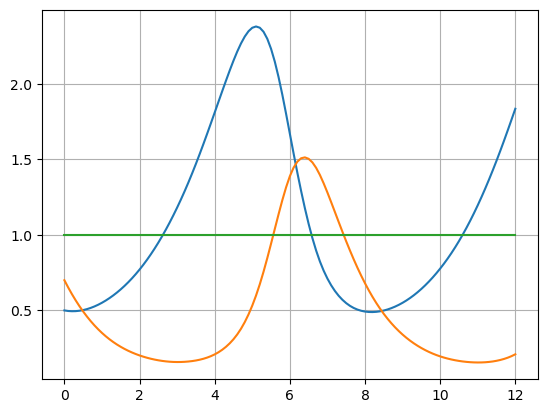

In [12]:
fig, axe = plt.subplots()
axe.plot(sol2.t, sol2.y.T)
axe.grid()

In [13]:
start = time.time()
solution = optimize.minimize(
    method='SLSQP',
    fun=functools.partial(integral, dt=dt),
    x0=x0.ravel(),
    bounds=bounds.ravel().reshape(-1, 2),
    constraints=(
        optimize.NonlinearConstraint(functools.partial(constraint1, dt=dt), lb=0, ub=0),
        optimize.NonlinearConstraint(functools.partial(constraint2, dt=dt), lb=0, ub=0)
    ),
)
stop = time.time()

In [14]:
stop - start

17.738842010498047

In [15]:
solution

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 1.3482596382553353
           x: [ 5.000e-01  5.150e-01 ...  8.212e-03  6.813e-03]
         nit: 51
         jac: [       nan -9.700e-02 ...  0.000e+00  0.000e+00]
        nfev: 18465
        njev: 51
 multipliers: [ 2.941e-01  5.462e-01 ...  1.377e-05 -3.735e-06]

In [16]:
It = integrand(solution.x).cumsum() * dt
It[-1]

1.3652597124542476

NameError: name 'sol' is not defined

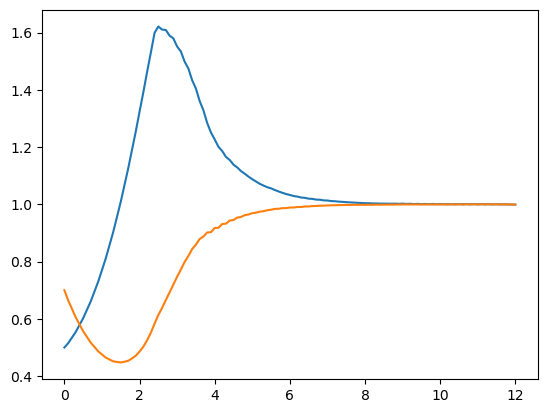

In [17]:
fig, axe = plt.subplots()
axe.plot(t, solution.x.reshape(3, -1).T[:,:2])
axe.plot(sol.t, sol.y.T[:,:2], "--", color="gray")
axe.set_title("Minimization Problem")
axe.set_xlabel("Time, $t$")
axe.set_ylabel("Coordinate, $x_i$")
axe.legend(["$x_1$(t)", "$x_2(t)$"])
axe.grid()

In [ ]:
x1lin = np.linspace(0.4, 1.7, 20)
x2lin = np.linspace(0.3, 1.1, 20)
X1, X2 = np.meshgrid(x1lin, x2lin)

In [ ]:
Z = integrand(np.array([X1, X2, X1])).reshape(X1.shape)

In [ ]:
fig, axe = plt.subplots()
axe.plot(solution.x.reshape(3, -1).T[:,0], solution.x.reshape(3, -1).T[:,1])
#axe.contour(X1, X2, Z)
axe.set_title("Minimization Problem")
axe.set_xlabel("Coordinate, $x_1$")
axe.set_ylabel("Coordinate, $x_2$")
axe.set_aspect("equal")
axe.grid()

In [ ]:
fig, axe = plt.subplots()
axe.plot(t, solution.x.reshape(3, -1).T[:,2])
axe.set_title("Minimization Problem")
axe.set_xlabel("Time, $t$")
axe.set_ylabel("Speed, $v(t)$")
axe.grid()

In [ ]:
fig, axe = plt.subplots()
axe.plot(t, It)
axe.set_title("Minimization Problem")
axe.set_xlabel("Time, $t$")
axe.set_ylabel("Integral, $I(t)$")
axe.grid()